# Unidad 5 — Sistemas Multi-Agente Modernos
## Notebook 02: LangChain Avanzado y LangGraph `[Intermedio ★★★☆☆]`

**Duración estimada:** 5-6 horas  
**Entorno:** `ia_multiagente` (Python 3.11)  
**Modelo por defecto:** Gemini 2.0 Flash · Alternativa: Ollama Llama 3.2  
**Costo estimado:** ~$0.02 con Gemini Flash · $0 con Ollama  
**Skill que se crea:** `external_skills/routing/task_classifier.py`

---

## Tabla de Contenidos

1. [Warm-Up y Repaso de U5_01](#1-warmup)
2. [¿Por qué LangGraph? Límites del AgentExecutor](#2-por-que-langgraph)
3. [Fundamentos de LangGraph: State, Nodes, Edges](#3-fundamentos)
   - 3.1 StateGraph y TypedDict
   - 3.2 Nodos y Aristas Condicionales
   - 3.3 Compilar y Visualizar el Grafo
4. [Patrones de Flujo en LangGraph](#4-patrones)
   - 4.1 Ciclo hasta convergencia (self-correction)
   - 4.2 Human-in-the-Loop con Breakpoints
   - 4.3 Checkpointing: estado persistente entre ejecuciones
5. [LCEL Avanzado: Streams y Runnable Parallel](#5-lcel-avanzado)
6. [Skill: Task Classifier — Enrutamiento Dinámico](#6-task-classifier)
7. [Proyecto: Sistema de Revisión de Código con Auto-Corrección](#7-proyecto)
8. [Visualización: Trazas con LangSmith (opcional)](#8-visualizacion)
9. [Resumen y Criterios de Evaluación](#9-resumen)

---

## Objetivos de Aprendizaje

Al completar esta notebook serás capaz de:
- Explicar qué limitaciones del `AgentExecutor` soluciona LangGraph
- Construir un `StateGraph` con nodos, aristas condicionales y ciclos controlados
- Implementar **human-in-the-loop** pausando el grafo con breakpoints
- Persistir estado entre ejecuciones usando checkpointing con sqlite
- Usar la skill `task_classifier` para enrutar tasks a agentes especializados

**Prerequisito:** U5_01 completada (AgentExecutor, tools, skill warm-up)

---
## 1. Warm-Up y Repaso de U5_01 <a id='1-warmup'></a>

In [2]:
# ============================================================
# WARM-UP: Entorno y Dependencias — U5_02
# ============================================================
import subprocess, sys, os
from pathlib import Path

def check_install(package, import_name=None):
    name = import_name or package.split('==')[0].replace('-', '_')
    try:
        __import__(name)
        print(f"  OK: {package}")
    except ImportError:
        print(f"  Instalando {package}...")
        subprocess.check_call([sys.executable, "-m", "pip", "install", package, "-q"])
        print(f"  Instalado: {package}")

packages = [
    ("langgraph==0.2.56",                "langgraph"),
    ("langchain==0.3.25",                "langchain"),
    ("langchain-openai==0.3.12",         "langchain_openai"),
    ("langchain-google-genai==2.1.4",    "langchain_google_genai"),
    # ("langchain-ollama==0.3.2",          "langchain_ollama"),
    ("langchain-community==0.3.24",      "langchain_community"),
    ("python-dotenv==1.1.0",             "dotenv"),
]

print("Verificando paquetes...")
for pkg, imp in packages:
    check_install(pkg, imp)

from dotenv import load_dotenv
load_dotenv(override=True)

# Resolver project root para external_skills
project_root = Path.cwd()
for _ in range(5):
    if (project_root / "external_skills").exists():
        break
    project_root = project_root.parent

if str(project_root) not in sys.path:
    sys.path.insert(0, str(project_root))

# Detectar backends disponibles
google_key     = os.environ.get("GOOGLE_API_KEY")
# openai_key     = os.environ.get("OPENAI_API_KEY")
openrouter_key = os.environ.get("OPENROUTER_API_KEY")

backend = (
    "OpenRouter"     if openrouter_key else
    "Gemini"         if google_key     else
    # "OpenAI"         if openai_key     else
    # "Ollama (local)"
    "Sin backend — configura OPENROUTER_API_KEY o GOOGLE_API_KEY en .env"
)

print(f"\nProject root: {project_root}")
print(f"Backend LLM activo: {backend}")


Verificando paquetes...
  OK: langgraph==0.2.56
  OK: langchain==0.3.25
  OK: langchain-openai==0.3.12
  OK: langchain-google-genai==2.1.4
  OK: langchain-community==0.3.24
  OK: python-dotenv==1.1.0

Project root: d:\Users\UCEMICH\Desktop\antigravity projects\IA NANOTECNOLOGIA\Antigravity-Nano-Research-Multiagentic-Core
Backend LLM activo: OpenRouter


In [3]:
from dotenv import load_dotenv
load_dotenv(override=True)  # recarga .env sin reiniciar el kernel

# Configurar LLM — prioridad: OpenRouter → Gemini → OpenAI → Ollama
import os

if os.environ.get("OPENROUTER_API_KEY"):
    from langchain_openai import ChatOpenAI
    OPENROUTER_MODEL = os.environ.get("OPENROUTER_MODEL", "google/gemini-2.5-flash")
    llm = ChatOpenAI(
        base_url="https://openrouter.ai/api/v1",
        api_key=os.environ["OPENROUTER_API_KEY"],
        model=OPENROUTER_MODEL,
        temperature=0,
        default_headers={
            "HTTP-Referer": "https://github.com/antigravity-nano",
            "X-Title": "Antigravity Nano IA Course",
        },
    )
    print(f"LLM: OpenRouter — {OPENROUTER_MODEL}")
elif os.environ.get("GOOGLE_API_KEY"):
    from langchain_google_genai import ChatGoogleGenerativeAI
    llm = ChatGoogleGenerativeAI(
        model="gemini-2.0-flash",
        temperature=0,
        google_api_key=os.environ["GOOGLE_API_KEY"]
    )
    print("LLM: Gemini 2.0 Flash")
# elif os.environ.get("OPENAI_API_KEY"):
    # from langchain_openai import ChatOpenAI
    # llm = ChatOpenAI(model="gpt-4o-mini", temperature=0, api_key=os.environ["OPENAI_API_KEY"])
    # print("LLM: GPT-4o-mini")
# else:
    # from langchain_ollama import ChatOllama
    # llm = ChatOllama(model="llama3.2", temperature=0)
    # print("LLM: Llama 3.2 via Ollama (local — puede ser lento)")

# Repaso rápido de U5_01 — verificar que la skill context_loader sigue disponible
from external_skills.agent_warmup.context_loader import warm_up, SKILL_METADATA
ctx = warm_up(domain="engineering")
print(f"\nSkill context_loader v{SKILL_METADATA['version']}: OK")
print("Warm-up completado.")


LLM: OpenRouter — google/gemini-2.5-flash

Skill context_loader v1.0.0: OK
Warm-up completado.


---
## 2. ¿Por qué LangGraph? Límites del AgentExecutor <a id='2-por-que-langgraph'></a>

En U5_01 usamos `AgentExecutor` — el wrapper de LangChain para el ciclo ReAct. Funciona perfectamente para agentes simples. Pero tiene limitaciones estructurales cuando queremos sistemas más complejos:

| Limitación | AgentExecutor | LangGraph |
|-----------|--------------|----------|
| **Flujo** | Lineal: thought → action → observation, siempre | Grafo arbitrario: nodos, ciclos, ramificaciones |
| **Estado** | Solo el scratchpad del LLM (se pierde entre corridas) | Estado tipado persistente (`TypedDict`) |
| **Condicionales** | Solo al nivel de tools | Aristas condicionales completas entre cualquier nodo |
| **Human-in-loop** | No soportado natively | Breakpoints de primera clase |
| **Múltiples agentes** | No, un solo agente | Sí, cada nodo puede ser un agente diferente |
| **Checkpointing** | No | Sí, con sqlite, PostgreSQL o Redis |
| **Streaming** | Limitado | Nativo token-by-token + node-by-node |

LangGraph modela los flujos de agentes como **grafos dirigidos** donde:
- **Nodos** = unidades de trabajo (funciones Python o agentes LangChain)
- **Aristas** = conexiones entre nodos
- **Aristas condicionales** = la arista que se activa depende del estado actual
- **Estado** = un diccionario tipado que fluye y se actualiza a través de los nodos

```
AgentExecutor:
  start → [thought→action→observation] x N → end
  (flujo fijo, lineal)

LangGraph:
  start → node_A → node_B ──────────────────→ end
                      │                        ↑
                      └──[condición]→ node_C ──┘
                      └──[ciclo]────→ node_A (volver a intentar)
  (flujo como grafo, completamente flexible)
```

---
## 3. Fundamentos de LangGraph: State, Nodes, Edges <a id='3-fundamentos'></a>

### 3.1 StateGraph y TypedDict

El **estado** en LangGraph es un `TypedDict` de Python. Es el "objeto compartido" que todos los nodos leen y escriben. LangGraph garantiza que las actualizaciones son thread-safe.

Un estado típico de agente:
```python
class AgentState(TypedDict):
    messages: list           # historial de mensajes
    current_task: str        # tarea actual
    iterations: int          # contador de iteraciones
    output: str              # resultado final
```

### 3.2 Nodos y Aristas Condicionales

Un **nodo** es cualquier función Python `(state: AgentState) -> dict` que devuelve un dict con las keys a actualizar en el estado.

In [4]:
# ============================================================
# WARM-UP: Sección 3 — LangGraph imports
# ============================================================
from typing import TypedDict, Annotated, List, Literal
from langgraph.graph import StateGraph, START, END
from langgraph.graph.message import add_messages
from langchain_core.messages import HumanMessage, AIMessage, SystemMessage

print("LangGraph imports OK")

LangGraph imports OK


In [5]:
# ────────────────────────────────────────────────────────────
# Output esperado: primer StateGraph — clasificador de queries
# ────────────────────────────────────────────────────────────

# Paso 1: Definir el estado del grafo
class QueryState(TypedDict):
    messages: Annotated[list, add_messages]  # add_messages acumula, no sobreescribe
    query_type: str      # 'math', 'definition', 'general'
    response: str
    iterations: int


# Paso 2: Definir los nodos — funciones (state) -> dict
def classify_query(state: QueryState) -> dict:
    """Nodo 1: Clasifica el tipo de query."""
    last_message = state["messages"][-1].content
    
    # Clasificación rule-based simple
    keywords_math = ["cuánto", "calcular", "suma", "resta", "multiplica", "divide", "porcentaje", "%"]
    keywords_def = ["qué es", "define", "significa", "concepto", "diferencia entre"]
    
    last_lower = last_message.lower()
    if any(kw in last_lower for kw in keywords_math):
        query_type = "math"
    elif any(kw in last_lower for kw in keywords_def):
        query_type = "definition"
    else:
        query_type = "general"
    
    print(f"  [classify_query] Tipo detectado: {query_type}")
    return {"query_type": query_type, "iterations": state.get("iterations", 0) + 1}


def handle_math(state: QueryState) -> dict:
    """Nodo 2a: Maneja queries matemáticas."""
    print("  [handle_math] Procesando...")
    prompt = f"Resuelve este problema matemático paso a paso: {state['messages'][-1].content}"
    response = llm.invoke(prompt)
    return {"response": response.content, "messages": [AIMessage(content=response.content)]}


def handle_definition(state: QueryState) -> dict:
    """Nodo 2b: Maneja queries de definición."""
    print("  [handle_definition] Procesando...")
    prompt = f"Define este concepto con ejemplos prácticos: {state['messages'][-1].content}"
    response = llm.invoke(prompt)
    return {"response": response.content, "messages": [AIMessage(content=response.content)]}


def handle_general(state: QueryState) -> dict:
    """Nodo 2c: Maneja queries generales."""
    print("  [handle_general] Procesando...")
    response = llm.invoke(state["messages"])
    return {"response": response.content, "messages": [AIMessage(content=response.content)]}


# Paso 3: Función de routing — determina qué arista tomar
def route_query(state: QueryState) -> Literal["handle_math", "handle_definition", "handle_general"]:
    """Arista condicional: decide el siguiente nodo según query_type."""
    return f'handle_{state["query_type"]}'


# Paso 4: Construir el grafo
builder = StateGraph(QueryState)

# Agregar nodos
builder.add_node("classify_query", classify_query)
builder.add_node("handle_math", handle_math)
builder.add_node("handle_definition", handle_definition)
builder.add_node("handle_general", handle_general)

# Agregar aristas
builder.add_edge(START, "classify_query")
builder.add_conditional_edges(
    "classify_query",           # desde este nodo
    route_query,                 # esta función decide
    {                            # mapa de decisión → nodo destino
        "handle_math": "handle_math",
        "handle_definition": "handle_definition",
        "handle_general": "handle_general",
    }
)
builder.add_edge("handle_math", END)
builder.add_edge("handle_definition", END)
builder.add_edge("handle_general", END)

# Paso 5: Compilar el grafo
graph = builder.compile()

print("Grafo compilado correctamente.")

Grafo compilado correctamente.


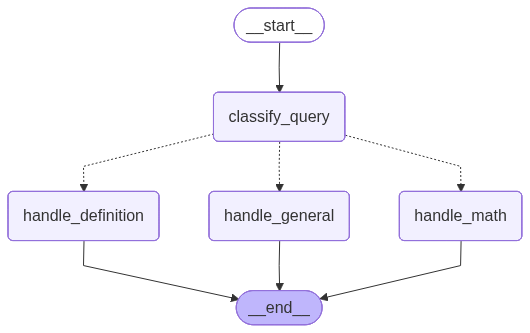

Grafo visualizado.


In [6]:
# Paso 6: Visualizar el grafo (requiere graphviz opcional)
try:
    from IPython.display import Image, display
    display(Image(graph.get_graph().draw_mermaid_png()))
    print("Grafo visualizado.")
except Exception:
    # Si graphviz no está instalado, mostramos la representación Mermaid
    mermaid_code = graph.get_graph().draw_mermaid()
    print("Diagrama Mermaid del grafo:")
    print(mermaid_code)

In [7]:
# Paso 7: Invocar el grafo con diferentes tipos de queries

test_queries = [
    "¿Cuánto es (150 * 0.18) + 50?",
    "¿Qué es un transformer en IA?",
    "Explícame los beneficios de los sistemas multi-agente.",
]

for query in test_queries:
    print(f"\nQuery: {query}")
    print("-" * 50)
    result = graph.invoke({
        "messages": [HumanMessage(content=query)],
        "query_type": "",
        "response": "",
        "iterations": 0
    })
    print(f"Ruta tomada: handle_{result['query_type']}")
    print(f"Respuesta: {result['response'][:200]}...")


Query: ¿Cuánto es (150 * 0.18) + 50?
--------------------------------------------------
  [classify_query] Tipo detectado: math
  [handle_math] Procesando...
Ruta tomada: handle_math
Respuesta: Vamos a resolver este problema paso a paso:

**Paso 1: Calcular la multiplicación dentro del paréntesis.**
$150 * 0.18$

Para calcular esto, podemos pensar en $0.18$ como $18/100$.
$150 * (18/100)$
$(...

Query: ¿Qué es un transformer en IA?
--------------------------------------------------
  [classify_query] Tipo detectado: definition
  [handle_definition] Procesando...
Ruta tomada: handle_definition
Respuesta: ¡Excelente pregunta! Un "Transformer" en IA es un concepto fundamental y revolucionario que ha impulsado gran parte del progreso reciente en el procesamiento del lenguaje natural (PLN) y más allá.

##...

Query: Explícame los beneficios de los sistemas multi-agente.
--------------------------------------------------
  [classify_query] Tipo detectado: general
  [handle_general] Procesan

**Output esperado:** La query de cálculo va a `handle_math` y muestra pasos matemáticos explícitos. La de definición va a `handle_definition` y ofrece explicación con ejemplos. La general va a `handle_general`. El routing es determinista y visible en los logs `[classify_query]`.

**Interpretación:** Este grafo trivial demuestra el poder conceptual de LangGraph: el flujo es explícito, auditable y modificable. Si quisieras cambiar el routing (ej: añadir un tipo `code` que va a un nodo diferente), solo agregas un nodo, una arista condicional y una línea en el dict del router — sin tocar el resto. Con `AgentExecutor` esto requeriría reestructurar el prompt system completo.

---
## 4. Patrones de Flujo en LangGraph <a id='4-patrones'></a>

### 4.1 Ciclo hasta Convergencia (Self-Correction)

El patrón más poderoso de LangGraph es el ciclo controlado: el grafo puede volver atrás a un nodo anterior si el resultado no cumple un criterio de calidad. Esto implementa la idea de **self-correction** de forma explícita y controlada.

In [8]:
# ────────────────────────────────────────────────────────────
# Output esperado: grafo con ciclo de corrección automática
# ────────────────────────────────────────────────────────────
from typing import Optional
from langchain_core.output_parsers import StrOutputParser
from langchain_core.prompts import ChatPromptTemplate


# Paso 1: Estado con contador para limitar el ciclo
class CorrectionState(TypedDict):
    task: str
    draft: str
    critique: str
    is_acceptable: bool
    iteration: int
    final_output: str


# Paso 2: Nodo de generación
def generate_draft(state: CorrectionState) -> dict:
    """Genera un borrador de la respuesta."""
    iteration = state.get("iteration", 0)
    prev_critique = state.get("critique", "")
    
    if prev_critique:
        prompt_text = (
            f"Tarea: {state['task']}\n\n"
            f"Tu borrador anterior tenía este problema: {prev_critique}\n\n"
            f"Genera un borrador mejorado que corrija específicamente ese problema."
        )
    else:
        prompt_text = f"Genera un texto conciso (3-4 oraciones) para: {state['task']}"
    
    draft = llm.invoke(prompt_text).content
    print(f"  [generate_draft] Iteración {iteration + 1}: {draft[:80]}...")
    return {"draft": draft, "iteration": iteration + 1}


# Paso 3: Nodo de crítica
def critique_draft(state: CorrectionState) -> dict:
    """Evalúa si el borrador cumple criterios de calidad."""
    eval_prompt = (
        f"Evalúa este texto: '{state['draft']}'\n\n"
        f"Responde SOLO con:\n"
        f"ACEPTABLE si tiene 3+ oraciones, es claro y específico.\n"
        f"RECHAZADO: [motivo exacto] si no cumple los criterios."
    )
    evaluation = llm.invoke(eval_prompt).content.strip()
    is_acceptable = evaluation.upper().startswith("ACEPTABLE")
    critique = "" if is_acceptable else evaluation.replace("RECHAZADO:", "").strip()
    
    print(f"  [critique_draft] Resultado: {'ACEPTABLE' if is_acceptable else 'RECHAZADO'}")
    if not is_acceptable:
        print(f"  Motivo: {critique[:80]}")
    
    return {"is_acceptable": is_acceptable, "critique": critique}


# Paso 4: Nodo de finalización
def finalize(state: CorrectionState) -> dict:
    """Guarda el output final aceptado."""
    print(f"  [finalize] Aceptado en iteración {state['iteration']}")
    return {"final_output": state["draft"]}


# Paso 5: Routing del ciclo
def should_continue(state: CorrectionState) -> Literal["finalize", "generate_draft"]:
    """Continúa corriendo o acepta el resultado."""
    # max_iterations = 3 para evitar loops infinitos
    if state["is_acceptable"] or state.get("iteration", 0) >= 3:
        return "finalize"
    return "generate_draft"


# Paso 6: Construir el grafo con ciclo
correction_builder = StateGraph(CorrectionState)
correction_builder.add_node("generate_draft", generate_draft)
correction_builder.add_node("critique_draft", critique_draft)
correction_builder.add_node("finalize", finalize)

correction_builder.add_edge(START, "generate_draft")
correction_builder.add_edge("generate_draft", "critique_draft")
correction_builder.add_conditional_edges(
    "critique_draft",
    should_continue,
    {"finalize": "finalize", "generate_draft": "generate_draft"}
)
correction_builder.add_edge("finalize", END)

correction_graph = correction_builder.compile()
print("Grafo de auto-corrección compilado.")

Grafo de auto-corrección compilado.


In [9]:
# Paso 7: Ejecutar el ciclo de corrección
result_correction = correction_graph.invoke({
    "task": "Explica en qué se diferencia LangGraph de LangChain AgentExecutor",
    "draft": "",
    "critique": "",
    "is_acceptable": False,
    "iteration": 0,
    "final_output": ""
})

print("\n" + "=" * 30)
print("OUTPUT FINAL ACEPTADO:")
print("=" * 30)
print(result_correction["final_output"])
print(f"\nTotal iteraciones: {result_correction['iteration']}")

  [generate_draft] Iteración 1: LangGraph extiende LangChain AgentExecutor al permitir la creación de grafos de ...
  [critique_draft] Resultado: ACEPTABLE
  [finalize] Aceptado en iteración 1

OUTPUT FINAL ACEPTADO:
LangGraph extiende LangChain AgentExecutor al permitir la creación de grafos de ejecución complejos, donde los pasos pueden ser condicionales, iterativos o incluso ramificados. Mientras que AgentExecutor sigue una secuencia lineal de herramientas y modelos, LangGraph ofrece un control más granular sobre el flujo de trabajo, permitiendo bucles, bifurcaciones y la definición de estados personalizados. Esto lo hace ideal para agentes más sofisticados que requieren una lógica de decisión compleja y una gestión de estado persistente a lo largo de múltiples interacciones. En esencia, LangGraph es una capa de orquestación más potente y flexible para construir agentes con LangChain.

Total iteraciones: 1


### 4.2 Human-in-the-Loop con Breakpoints

Los breakpoints permiten **pausar** el grafo antes de ejecutar un nodo crítico y esperar confirmación humana. Esto es crucial para flujos que involucran acciones irreversibles (enviar emails, escribir a bases de datos, hacer commits, etc.).

In [10]:
# ────────────────────────────────────────────────────────────
# Output esperado: grafo con human-in-the-loop + checkpointing
# ────────────────────────────────────────────────────────────
from langgraph.checkpoint.memory import MemorySaver

# Paso 1: Estado con campo de aprobación humana
class ApprovalState(TypedDict):
    task: str
    plan: str
    human_approved: bool
    execution_result: str


def create_plan(state: ApprovalState) -> dict:
    """Genera un plan de acción para la tarea."""
    prompt = f"Crea un plan de 3 pasos para: {state['task']}"
    plan = llm.invoke(prompt).content
    print(f"  [create_plan] Plan generado.")
    return {"plan": plan}


def execute_plan(state: ApprovalState) -> dict:
    """Ejecuta el plan aprobado."""
    # En producción: llamadas a APIs, escrituras a DB, etc.
    print(f"  [execute_plan] Ejecutando plan aprobado...")
    result = f"Plan ejecutado satisfactoriamente: {state['plan'][:100]}..."
    return {"execution_result": result}


# Paso 2: Construir el grafo con breakpoint ANTES de execute_plan
approval_builder = StateGraph(ApprovalState)
approval_builder.add_node("create_plan", create_plan)
approval_builder.add_node("execute_plan", execute_plan)

approval_builder.add_edge(START, "create_plan")
approval_builder.add_edge("create_plan", "execute_plan")
approval_builder.add_edge("execute_plan", END)

# Paso 3: Compilar con checkpointer (persistencia en memoria) y breakpoint
checkpointer = MemorySaver()
approval_graph = approval_builder.compile(
    checkpointer=checkpointer,
    interrupt_before=["execute_plan"]  # PAUSA aquí y espera input humano
)

print("Grafo con human-in-the-loop compilado.")
print("Breakpoint configurado en: execute_plan")

Grafo con human-in-the-loop compilado.
Breakpoint configurado en: execute_plan


In [11]:
# Paso 4: Ejecutar hasta el breakpoint
# thread_id identifica la sesión — permite reanudar después
config = {"configurable": {"thread_id": "demo_hitl_001"}}

print("Paso 1: Ejecutar hasta el breakpoint...")
state_at_breakpoint = approval_graph.invoke(
    {
        "task": "Publicar el reporte de investigación en el blog del laboratorio",
        "plan": "",
        "human_approved": False,
        "execution_result": ""
    },
    config=config
)

print("\n--- BREAKPOINT ALCANZADO ---")
print("Plan generado (pendiente de aprobación):")
print(state_at_breakpoint["plan"])
print("\n[El grafo está PAUSADO. No se ha ejecutado ninguna acción todavía.]")

Paso 1: Ejecutar hasta el breakpoint...
  [create_plan] Plan generado.

--- BREAKPOINT ALCANZADO ---
Plan generado (pendiente de aprobación):
¡Claro! Aquí tienes un plan de 3 pasos para publicar el reporte de investigación en el blog del laboratorio:

---

## Plan de 3 Pasos para Publicar el Reporte de Investigación en el Blog del Laboratorio

Este plan está diseñado para asegurar una publicación efectiva y atractiva, maximizando el alcance y la comprensión de tu investigación.

---

### **Paso 1: Preparación del Contenido y Materiales (Pre-Publicación)**

Este paso se enfoca en transformar el reporte de investigación en un formato adecuado para el blog, haciéndolo accesible y atractivo para una audiencia más amplia.

*   **1.1. Resumen Ejecutivo y Puntos Clave (Blog-Friendly):**
    *   **Acción:** Redacta un resumen conciso y atractivo del reporte de investigación. Este no es el *abstract* científico, sino una introducción que capte la atención del lector.
    *   **Detalles:**
     

In [ ]:
# Paso 5: Simular la aprobación humana y reanudar el grafo
# En una app real esto vendría de un formulario web, Slack bot, etc.

# Obtener el estado guardado en el checkpointer
saved_state = approval_graph.get_state(config)
print("Estado guardado en checkpoint:")
print(f"  Siguiente nodo a ejecutar: {saved_state.next}")

# Simular aprobación (en producción: leer de input del usuario)
human_decision = "yes"  # cambiar a "no" para cancelar

if human_decision.lower() == "yes":
    print("\nAprobado por el humano. Reanudando ejecución...")
    # Reanudar el grafo desde donde se pausó
    final_state = approval_graph.invoke(None, config=config)
    print("\nResultado de ejecución:")
    print(final_state["execution_result"])
else:
    print("\nPlan rechazado por el humano. Flujo cancelado.")

Estado guardado en checkpoint:
  Siguiente nodo a ejecutar: ('execute_plan',)

Aprobado por el humano. Reanudando ejecución...
  [execute_plan] Ejecutando plan aprobado...

Resultado de ejecución:
Plan ejecutado satisfactoriamente: ¡Claro! Aquí tienes un plan de 3 pasos para publicar el reporte de investigación en el blog del labo...


**Output esperado:** El grafo genera el plan y luego se detiene. El mensaje `[El grafo está PAUSADO]` confirma que aún no ejecutó `execute_plan`. Al pasar `None` como input con el mismo `config`, LangGraph reanuda desde el checkpoint donde se pausó y ejecuta el nodo pendiente.

**Interpretación:** Este patrón es crítico en sistemas de IA en producción. Ningún agente autónomo debería ejecutar acciones irreversibles (publicar, enviar, escribir) sin algún nivel de supervisión humana. LangGraph formaliza este requisito con `interrupt_before`, haciendo que la pausa sea parte del diseño del grafo, no un afterthought.

### 4.3 Checkpointing: Estado Persistente

In [ ]:
# Checkpointing con SQLite — persiste entre reinicios de kernel
try:
    from langgraph.checkpoint.sqlite import SqliteSaver
    import sqlite3
    
    # Uso de context manager para cerrar la conexión correctamente
    conn = sqlite3.connect("./agent_checkpoints.db", check_same_thread=False)
    sqlite_checkpointer = SqliteSaver(conn)
    print("SQLite checkpointer disponible — el estado persiste entre sesiones.")
    sqlite_available = True
except ImportError:
    print("langgraph-checkpoint-sqlite no instalado.")
    print("Instalar con: pip install langgraph-checkpoint-sqlite")
    print("Usando MemorySaver por ahora (solo dura en memoria).")
    sqlite_available = False

print("\nComparación de checkpointers:")
print("MemorySaver  → En memoria, se pierde al reiniciar el kernel")
print("SqliteSaver  → SQLite local, persiste entre sesiones")
print("PostgresSaver→ PostgreSQL, para producción multi-usuario")

langgraph-checkpoint-sqlite no instalado.
Instalar con: pip install langgraph-checkpoint-sqlite
Usando MemorySaver por ahora (solo dura en memoria).

Comparación de checkpointers:
MemorySaver  → En memoria, se pierde al reiniciar el kernel
SqliteSaver  → SQLite local, persiste entre sesiones
PostgresSaver→ PostgreSQL, para producción multi-usuario


---
## 5. LCEL Avanzado: Streams y Runnable Parallel <a id='5-lcel-avanzado'></a>

LCEL (LangChain Expression Language) tiene dos características avanzadas que potencian significativamente el rendimiento: streaming token a token y paralelización de cadenas.

In [ ]:
# ────────────────────────────────────────────────────────────
# Output esperado: streaming y ejecución paralela con LCEL
# ────────────────────────────────────────────────────────────
from langchain_core.runnables import RunnableParallel
from langchain_core.prompts import ChatPromptTemplate
from langchain_core.output_parsers import StrOutputParser

# Paso 1: Streaming — tokens llegan mientras el modelo los genera
print("STREAMING de respuesta:")
print("-" * 40)
stream_prompt = ChatPromptTemplate.from_template("Explica en 3 puntos: {tema}")
stream_chain = stream_prompt | llm | StrOutputParser()

# .stream() devuelve un iterador de chunks
for chunk in stream_chain.stream({"tema": "ventajas de LangGraph sobre AgentExecutor"}):
    print(chunk, end="", flush=True)
print("\n")

STREAMING de respuesta:
----------------------------------------
Aquí tienes las 3 ventajas principales de LangGraph sobre AgentExecutor:

1.  **Control de Flujo Explícito y Complejo:** LangGraph ofrece un control de flujo mucho más granular y explícito. Mientras que AgentExecutor sigue una secuencia lineal de "pensar, actuar, observar" (o variaciones de esto), LangGraph permite definir un grafo de estados y transiciones arbitrario. Esto significa que puedes crear bucles condicionales, bifurcaciones, uniones, y manejar estados intermedios de manera mucho más sofisticada. Por ejemplo, puedes definir que si una herramienta falla, se intente otra, o que si se alcanza un cierto estado, se vuelva a un paso anterior. AgentExecutor es más rígido en su ejecución.

2.  **Manejo de Estado Persistente y Compartido:** LangGraph está diseñado para manejar y persistir el estado a lo largo de múltiples pasos y nodos del grafo. Cada nodo puede modificar el estado global, y este estado se pasa explícit

In [ ]:
# Paso 2: RunnableParallel — ejecutar múltiples cadenas al mismo tiempo
import time

# Definir dos cadenas que haremos correr en paralelo
resumen_chain = (
    ChatPromptTemplate.from_template("Resume en 1 oración: {texto}")
    | llm
    | StrOutputParser()
)

keywords_chain = (
    ChatPromptTemplate.from_template("Lista las 5 palabras clave de: {texto}")
    | llm
    | StrOutputParser()
)

# RunnableParallel los ejecuta simultáneamente
parallel_chain = RunnableParallel(
    resumen=resumen_chain,
    keywords=keywords_chain
)

texto_test = """LangGraph es un framework para construir aplicaciones con LLMs 
usando grafos de estado. Permite crear flujos complejos con ciclos, condicionales,
y persistencia de estado entre ejecuciones."""

print("Ejecutando cadenas en PARALELO...")
start = time.time()
result_parallel = parallel_chain.invoke({"texto": texto_test})
elapsed = time.time() - start

print(f"Completado en {elapsed:.2f}s (ambas cadenas corrieron simultáneamente)")
print("\nResumen:", result_parallel["resumen"])
print("\nKeywords:", result_parallel["keywords"])

Ejecutando cadenas en PARALELO...
Completado en 1.11s (ambas cadenas corrieron simultáneamente)

Resumen: LangGraph es un framework que facilita la construcción de aplicaciones complejas con LLMs mediante grafos de estado, permitiendo flujos con ciclos, condicionales y persistencia de estado.

Keywords: Aquí están las 5 palabras clave de la descripción proporcionada:

1. **LangGraph**
2. **Framework**
3. **LLMs** (o Modelos de Lenguaje Grandes)
4. **Grafos de estado**
5. **Flujos**


**Interpretación:** `RunnableParallel` reduce el tiempo total al ejecutar las cadenas simultáneamente. Si cada cadena tarda 2 segundos, la versión secuencial tardaría 4 segundos; la paralela tarda ~2 segundos. Este patrón es fundamental cuando un agente necesita hacer múltiples análisis independientes de la misma información.

---
## 6. Skill: Task Classifier — Enrutamiento Dinámico <a id='6-task-classifier'></a>

La skill `task_classifier` encapsula el patrón de routing que vimos en la sección 3 en un módulo reutilizable. Esta skill es clave en sistemas multi-agente — permite que un agente orquestador dirija cada tarea al sub-agente especializado correcto.

In [ ]:
# ────────────────────────────────────────────────────────────
# Output esperado: usar la skill task_classifier en un grafo LangGraph
# ────────────────────────────────────────────────────────────

# Paso 1: Cargar la skill
from external_skills.routing.task_classifier import classify, ROUTING_RULES, SKILL_METADATA as TC_META

print(f"Skill cargada: {TC_META['name']} v{TC_META['version']}")
print(f"Dominios con reglas: {list(ROUTING_RULES.keys())}")

Skill cargada: task_classifier v1.0.0
Dominios con reglas: ['code_generation', 'data_analysis', 'research', 'writing', 'question_answering']


In [ ]:
# Paso 2: Clasificar tasks de prueba
test_tasks = [
    "Analiza este dataset de nanopartículas y encuentra clusters",
    "Genera un código Python para visualizar una red neuronal",
    "¿Cuál es la diferencia entre DFT y MD en simulación molecular?",
    "Optimiza la estructura de este agente para menor latencia",
]

available_agents = ["data_analyst", "code_generator", "researcher", "optimizer"]

print("Clasificando tasks:")
print("=" * 60)
for task in test_tasks:
    result = classify(task, available_agents=available_agents)
    print(f"Task: {task[:50]}...")
    print(f"  → Agente: {result['recommended_agent']} | Confianza: {result['confidence']:.0%}")
    print()

Clasificando tasks:
Task: Analiza este dataset de nanopartículas y encuentra...
  → Agente: data_analyst | Confianza: 75%

Task: Genera un código Python para visualizar una red ne...
  → Agente: code_generator | Confianza: 40%

Task: ¿Cuál es la diferencia entre DFT y MD en simulació...
  → Agente: data_analyst | Confianza: 35%

Task: Optimiza la estructura de este agente para menor l...
  → Agente: data_analyst | Confianza: 5%



In [ ]:
# Paso 3: Integrar task_classifier en un StateGraph como nodo de routing

class RouterState(TypedDict):
    task: str
    classified_agent: str
    confidence: float
    result: str


def routing_node(state: RouterState) -> dict:
    """Nodo que usa la skill task_classifier para enrutar."""
    classification = classify(
        state["task"],
        available_agents=["researcher", "code_generator", "data_analyst"]
    )
    print(f"  [routing_node] → {classification['recommended_agent']} ({classification['confidence']:.0%})")
    return {
        "classified_agent": classification["recommended_agent"],
        "confidence": classification["confidence"]
    }


def researcher_node(state: RouterState) -> dict:
    response = llm.invoke(
        f"Como investigador experto, responde: {state['task']}"
    ).content
    return {"result": f"[RESEARCHER] {response}"}


def code_generator_node(state: RouterState) -> dict:
    response = llm.invoke(
        f"Genera código Python bien comentado para: {state['task']}"
    ).content
    return {"result": f"[CODE_GENERATOR] {response}"}


def data_analyst_node(state: RouterState) -> dict:
    response = llm.invoke(
        f"Como analista de datos, proporciona un plan de análisis para: {state['task']}"
    ).content
    return {"result": f"[DATA_ANALYST] {response}"}


def route_to_agent(state: RouterState) -> str:
    agent = state.get("classified_agent", "researcher")
    valid = {"researcher", "code_generator", "data_analyst"}
    return agent if agent in valid else "researcher"


# Construir el grafo
router_builder = StateGraph(RouterState)
router_builder.add_node("routing_node", routing_node)
router_builder.add_node("researcher", researcher_node)
router_builder.add_node("code_generator", code_generator_node)
router_builder.add_node("data_analyst", data_analyst_node)

router_builder.add_edge(START, "routing_node")
router_builder.add_conditional_edges(
    "routing_node",
    route_to_agent,
    {"researcher": "researcher", "code_generator": "code_generator", "data_analyst": "data_analyst"}
)
router_builder.add_edge("researcher", END)
router_builder.add_edge("code_generator", END)
router_builder.add_edge("data_analyst", END)

router_graph = router_builder.compile()
print("Grafo con skill de routing compilado.")

Grafo con skill de routing compilado.


In [ ]:
# Paso 4: Probar el grafo completo
tasks_to_test = [
    "¿Cómo se compara LangGraph con AutoGen para sistemas multi-agente?",
    "Escribe una función Python para calcular la energía de Fermi en un metal nanoestructurado",
]

for task in tasks_to_test:
    print(f"\nTask: {task[:60]}...")
    result = router_graph.invoke({
        "task": task,
        "classified_agent": "",
        "confidence": 0.0,
        "result": ""
    })
    print(f"Agente asignado: {result['classified_agent']}")
    print(f"Resultado: {result['result'][:200]}...")


Task: ¿Cómo se compara LangGraph con AutoGen para sistemas multi-a...
  [routing_node] → researcher (5%)
Agente asignado: researcher
Resultado: [RESEARCHER] Como investigador experto en sistemas multi-agente, puedo ofrecer una comparación detallada entre LangGraph y AutoGen, destacando sus fortalezas, debilidades y casos de uso ideales. Ambos...

Task: Escribe una función Python para calcular la energía de Fermi...
  [routing_node] → code_generator (35%)
Agente asignado: code_generator
Resultado: [CODE_GENERATOR] ¡Claro! Aquí tienes una función Python bien comentada para calcular la energía de Fermi en un metal nanoestructurado.

```python
import numpy as np

def energia_fermi_nanoestructurado...


---
## 7. Proyecto: Sistema de Revisión de Código con Auto-Corrección <a id='7-proyecto'></a>

Integración completa: grafo con ciclo de corrección + skill warm-up de engineering + task_classifier.

In [ ]:
# ============================================================
# PROYECTO: Code Review System con LangGraph
# ============================================================
from external_skills.agent_warmup.context_loader import warm_up as warmup_ctx

# Paso 1: Warm-up del dominio de engineering
eng_context = warmup_ctx(domain="engineering")

# Paso 2: Estado del sistema de revisión
class CodeReviewState(TypedDict):
    code: str
    review: str
    improved_code: str
    review_passed: bool
    iteration: int
    final_code: str


def review_code(state: CodeReviewState) -> dict:
    """Revisa el código según mejores prácticas de ingeniería."""
    prompt = (
        f"{eng_context['system_context']}\n\n"
        f"Revisa este código Python e identifica problemas:\n"
        f"```python\n{state['code']}\n```\n\n"
        f"Si es aceptable (sin problemas críticos), responde comenzando con 'APROBADO:'.\n"
        f"Si hay problemas, responde comenzando con 'PROBLEMAS:' y lista los problemas."
    )
    review = llm.invoke(prompt).content
    review_passed = review.strip().upper().startswith("APROBADO")
    print(f"  [review_code] Iteración {state.get('iteration', 0) + 1}: {'APROBADO' if review_passed else 'PROBLEMAS detectados'}")
    return {
        "review": review,
        "review_passed": review_passed,
        "iteration": state.get("iteration", 0) + 1
    }


def improve_code(state: CodeReviewState) -> dict:
    """Mejora el código basándose en la revisión."""
    prompt = (
        f"Código original:\n```python\n{state['code']}\n```\n\n"
        f"Problemas identificados:\n{state['review']}\n\n"
        f"Proporciona el código corregido completo. Solo el código, sin explicaciones extras."
    )
    improved = llm.invoke(prompt).content
    # Extraer el bloque de código si viene en markdown
    if "```python" in improved:
        improved = improved.split("```python")[1].split("```")[0].strip()
    print(f"  [improve_code] Código mejorado generado.")
    return {"code": improved, "improved_code": improved}


def finalize_review(state: CodeReviewState) -> dict:
    print(f"  [finalize] Código aprobado en iteración {state['iteration']}.")
    return {"final_code": state["code"]}


def should_retry_review(state: CodeReviewState) -> Literal["finalize_review", "improve_code"]:
    if state["review_passed"] or state.get("iteration", 0) >= 3:
        return "finalize_review"
    return "improve_code"


# Paso 3: Construir el grafo
cr_builder = StateGraph(CodeReviewState)
cr_builder.add_node("review_code", review_code)
cr_builder.add_node("improve_code", improve_code)
cr_builder.add_node("finalize_review", finalize_review)

cr_builder.add_edge(START, "review_code")
cr_builder.add_conditional_edges(
    "review_code",
    should_retry_review,
    {"finalize_review": "finalize_review", "improve_code": "improve_code"}
)
cr_builder.add_edge("improve_code", "review_code")
cr_builder.add_edge("finalize_review", END)

code_review_graph = cr_builder.compile()
print("Sistema de revisión de código compilado.")

Sistema de revisión de código compilado.


In [ ]:
# Paso 4: Probar con código que tiene problemas intencionales
codigo_con_problemas = """
def calcular_estadisticas(datos):
    total = 0
    for d in datos:
        total += d
    media = total / len(datos)
    varianza = sum([(x - media)**2 for x in datos]) / len(datos)
    try:
        resultado = {'media': media, 'varianza': varianza}
        print('Calculo exitoso')
        return resultado
    except:
        print('Error')
        return None
"""

print("Código original:")
print(codigo_con_problemas)
print("Iniciando revisión...")

result_cr = code_review_graph.invoke({
    "code": codigo_con_problemas,
    "review": "",
    "improved_code": "",
    "review_passed": False,
    "iteration": 0,
    "final_code": ""
})

print("\n" + "=" * 60)
print("CÓDIGO FINAL (después de auto-corrección):")
print("=" * 60)
print(result_cr["final_code"])
print(f"\nIteraciones de revisión: {result_cr['iteration']}")

Código original:

def calcular_estadisticas(datos):
    total = 0
    for d in datos:
        total += d
    media = total / len(datos)
    varianza = sum([(x - media)**2 for x in datos]) / len(datos)
    try:
        resultado = {'media': media, 'varianza': varianza}
        print('Calculo exitoso')
        return resultado
    except:
        print('Error')
        return None

Iniciando revisión...
  [review_code] Iteración 1: PROBLEMAS detectados
  [improve_code] Código mejorado generado.
  [review_code] Iteración 2: PROBLEMAS detectados
  [improve_code] Código mejorado generado.
  [review_code] Iteración 3: PROBLEMAS detectados
  [finalize] Código aprobado en iteración 3.

CÓDIGO FINAL (después de auto-corrección):
from typing import List, Dict, Union

def calcular_estadisticas(datos: List[Union[int, float]]) -> Dict[str, float]:
    """
    Calcula la media y la varianza poblacional de una lista de números.

    Args:
        datos: Una lista de números (enteros o flotantes).

  

---
## 8. Visualización: Trazas con LangSmith (opcional) <a id='8-visualizacion'></a>

In [ ]:
# LangSmith trazas — requiere LANGCHAIN_API_KEY en .env
# Documentación: https://docs.smith.langchain.com/

langsmith_key = os.environ.get("LANGCHAIN_API_KEY")

if langsmith_key:
    os.environ["LANGCHAIN_TRACING_V2"] = "true"
    os.environ["LANGCHAIN_PROJECT"] = "U5_02_LangGraph_Demo"
    print("LangSmith tracing habilitado.")
    print("Ver trazas en: https://smith.langchain.com")
    
    # Re-ejecutar el grafo de routing con tracing activo
    result_traced = router_graph.invoke({
        "task": "¿Cómo diseño un agente ReAct eficiente?",
        "classified_agent": "",
        "confidence": 0.0,
        "result": ""
    })
    print(f"\nEjecución trazada. Agente: {result_traced['classified_agent']}")
else:
    print("LANGCHAIN_API_KEY no configurada — tracing deshabilitado.")
    print("Para habilitarlo:")
    print("  1. Crear cuenta en https://smith.langchain.com")
    print("  2. Agregar LANGCHAIN_API_KEY al archivo .env")
    print("  3. Re-ejecutar esta celda")
    print("\nLas trazas muestran: flujo de nodos, tokens por paso, latencias, errores.")

# Usar la skill trace_annotator del proyecto
try:
    from external_skills.observability.trace_annotator import SKILL_METADATA as TA_META
    print(f"\nSkill disponible: {TA_META['name']} v{TA_META['version']}")
    print("Profundizar en observabilidad → U5_08 Orquestación Avanzada")
except ImportError:
    print("trace_annotator no disponible — verificar external_skills/observability/")

LangSmith tracing habilitado.
Ver trazas en: https://smith.langchain.com
  [routing_node] → researcher (5%)

Ejecución trazada. Agente: researcher

Skill disponible: trace_annotator v1.0.0
Profundizar en observabilidad → U5_08 Orquestación Avanzada


---
## 9. Resumen y Criterios de Evaluación <a id='9-resumen'></a>

### Conceptos Clave de esta Notebook

| Concepto | Definición | Implementado en |
|----------|------------|------------------|
| **StateGraph** | Grafo de flujo de agentes con estado tipado compartido entre nodos | Sección 3 |
| **Nodo** | Función Python que lee el estado, actúa, y devuelve updates parciales | Secciones 3, 4, 6, 7 |
| **Arista condicional** | El próximo nodo se decide en tiempo de ejecución según el estado | Secciones 3, 4, 6 |
| **Ciclo de corrección** | Nodo que puede enviarse de vuelta al mismo o anterior nodo hasta que la calidad es aceptable | Secciones 4.1, 7 |
| **Human-in-the-Loop** | Breakpoint que pausa el grafo y espera input humano antes de continuar | Sección 4.2 |
| **Checkpointing** | Guardar el estado completo del grafo para reanudar desde cualquier punto | Sección 4.3 |
| **RunnableParallel** | LCEL para ejecutar múltiples cadenas simultáneamente | Sección 5 |
| **Task Classifier** | Skill de routing que asigna tareas al agente especializado correcto | Sección 6 |

### Criterios de Evaluación

- [ ] Construir un `StateGraph` con al menos 3 nodos y una arista condicional
- [ ] Implementar un ciclo de corrección que termine con `max_iterations` como guardia
- [ ] Demostrar human-in-the-loop: grafo pausado → estado inspeccionado → reanudado
- [ ] Usar `task_classifier` skill en un grafo de routing entre 2+ agentes especializados
- [ ] Explicar la diferencia entre `MemorySaver` y `SqliteSaver` y cuándo usar cada uno

### Ejercicio de Extensión

Construye un sistema de generación de reportes técnicos con:
1. Nodo de análisis del tema solicitado
2. Nodo de búsqueda de información (tool o mock)
3. Nodo de redacción del reporte
4. Nodo de revisión de calidad con ciclo de corrección (max 2 intentos)
5. Nodo de human-in-the-loop para aprobación antes de "publicar"
6. Checkpointing con SQLite para que el reporte persista entre sesiones

### Próxima Notebook

En **U5_03 — CrewAI y Sistemas Multi-Agente** pasamos al nivel de coordinación de múltiples agentes especializados trabajando en paralelo y en secuencia, con roles definidos, backstories, y supervisión delegada.

---
*Notebook generada siguiendo el PROTOCOLO_UNIDAD_5_MULTIAGENTE.md v1.1.0*  
*Antigravity-Nano-Research — Unit 05 Multi-Agent Systems — Marzo 2026*